In [1]:
import sys
sys.path.append('..')
sys.path.append('../Modules')

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import Modules.analysis as analysis

In [2]:
sims_dir = '/home/drfrbc/Neural-Modeling/simulations/2025-07-21-16-10-all_inh_rhythmic_depth_sweep_upper' # folder containing simulation folders

sim_dirs = [os.path.join(sims_dir, sim_dir) for sim_dir in os.listdir(sims_dir)] # every directory in sims_dir

In [3]:
# gather spike tables into 1.

import os
import pandas as pd

# Suppose sim_dirs is your list of simulation directories
# import your analysis module
import Modules.analysis as analysis

# Accumulate data in a list of rows
all_rows = []

for sim_dir in sim_dirs:
    # Read dSpike_table.csv
    dSpike_path = os.path.join(sim_dir, "dSpike_table.csv")
    if not os.path.exists(dSpike_path):
        print(f"Skipping {sim_dir}, {dSpike_path} not found.")
        continue
    df = pd.read_csv(dSpike_path)
    
    # Get CI_amplitude from parameters
    try:
        params = analysis.DataReader.load_parameters(sim_dir)
        CI_amplitude = params.h_i_amplitude
        perisomatic_rhythmic_depth = params.inh_syn_properties['perisomatic']['rhythmic_depth']
        distal_rhythmic_depth = params.inh_syn_properties['distal_basal']['rhythmic_depth']
    except Exception as e:
        print(f"Error loading parameters from {sim_dir}: {e}")
        CI_amplitude = None

    # Add sim_dir and CI_amplitude columns
    df['sim_dir'] = sim_dir
    df['CI_amplitude'] = CI_amplitude
    df['perisomatic_rhythmic_depth'] = perisomatic_rhythmic_depth
    df['distal_rhythmic_depth'] = distal_rhythmic_depth

    # Append to master list
    all_rows.append(df)

# Combine all rows into one DataFrame
all_data = pd.concat(all_rows, ignore_index=True)


--No graphics will be displayed.


In [4]:
all_data

,Unnamed: 0,Segment_Type,Total_NMDA_Spikes,Total_NA_Spikes,Total_CA_Spikes,Soma_Spike_Rate,sim_dir,CI_amplitude,perisomatic_rhythmic_depth,distal_rhythmic_depth
0,0,apic,3942.4,7.5,6.1,0.833333,/home/drfrbc/Neural-Modeling/simulations/2025-...,0.0,0.05,0.05
1,1,dend,3981.6,17.4,0.0,0.833333,/home/drfrbc/Neural-Modeling/simulations/2025-...,0.0,0.05,0.05
2,0,apic,3985.4,7.4,10.2,0.633333,/home/drfrbc/Neural-Modeling/simulations/2025-...,0.0,0.10,0.10
3,1,dend,3989.4,17.4,0.0,0.633333,/home/drfrbc/Neural-Modeling/simulations/2025-...,0.0,0.10,0.10
4,0,apic,4051.3,7.8,9.4,0.866667,/home/drfrbc/Neural-Modeling/simulations/2025-...,0.0,0.15,0.15
5,1,dend,4024.4,16.2,0.0,0.866667,/home/drfrbc/Neural-Modeling/simulations/2025-...,0.0,0.15,0.15
6,0,apic,4113.6,5.9,15.4,1.400000,/home/drfrbc/Neural-Modeling/simulations/2025-...,0.0,0.20,0.20
7,1,dend,4032.0,12.9,0.0,1.400000,/home/drfrbc/Neural-Modeling/simulations/2025-...,0.0,0.20,0.20
8,0,apic,4278.2,11.1,19.8,3.000000,/home/drfrbc/Neural-Modeling/simulations/2025-...,0.0,0.30,0.30
9,1,dend,4112.1,16.3,0.0,3.000000,/home/drfrbc/Neural-Modeling/simulations/2025-...,0.0,0.30,0.30


In [5]:
apical_data = all_data[all_data['Segment_Type'] == 'apic']

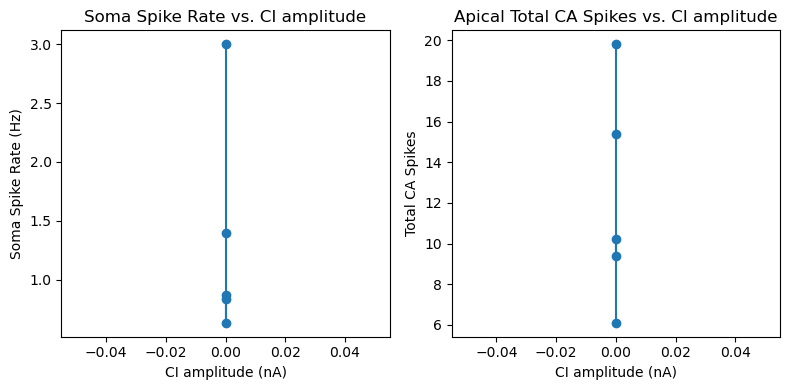

In [6]:
import matplotlib.pyplot as plt

# Scatter plot: CI_amplitude vs. Soma_Spike_Rate
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(apical_data['CI_amplitude'], apical_data['Soma_Spike_Rate'])
plt.scatter(apical_data['CI_amplitude'], apical_data['Soma_Spike_Rate'])
plt.xlabel('CI amplitude (nA)')
plt.ylabel('Soma Spike Rate (Hz)')
plt.title('Soma Spike Rate vs. CI amplitude')
# plt.savefig(os.path.join(sims_dir, 'Soma FR/I.png')) # don't need because it is one figure.

# Scatter plot: CI_amplitude vs. Total_CA_Spikes
plt.subplot(1, 2, 2)
plt.plot(apical_data['CI_amplitude'], apical_data['Total_CA_Spikes'])
plt.scatter(apical_data['CI_amplitude'], apical_data['Total_CA_Spikes'])
plt.xlabel('CI amplitude (nA)')
plt.ylabel('Total CA Spikes')
plt.title('Apical Total CA Spikes vs. CI amplitude')
plt.savefig(os.path.join(sims_dir, 'Soma and Ca2+ FR_I.png'))

plt.tight_layout()
plt.show()

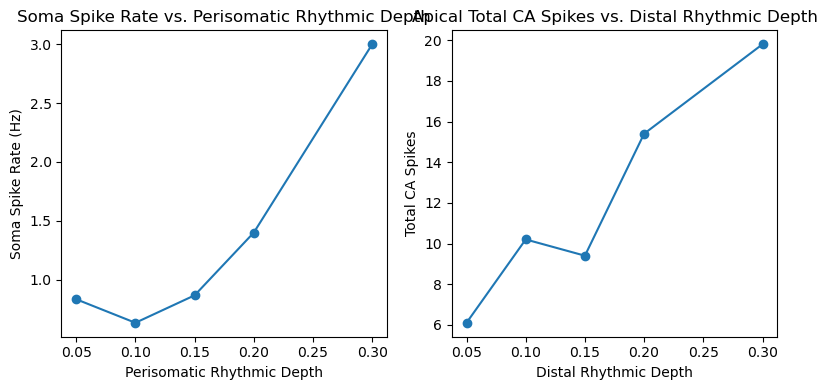

In [7]:
import matplotlib.pyplot as plt

# Scatter plot: CI_amplitude vs. Soma_Spike_Rate
plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(apical_data['perisomatic_rhythmic_depth'], apical_data['Soma_Spike_Rate'])
plt.scatter(apical_data['perisomatic_rhythmic_depth'], apical_data['Soma_Spike_Rate'])
plt.xlabel('Perisomatic Rhythmic Depth')
plt.ylabel('Soma Spike Rate (Hz)')
plt.title('Soma Spike Rate vs. Perisomatic Rhythmic Depth')
# plt.savefig(os.path.join(sims_dir, 'Soma FR/I.png')) # don't need because it is one figure.

# Scatter plot: CI_amplitude vs. Total_CA_Spikes
plt.subplot(1, 2, 2)
plt.plot(apical_data['distal_rhythmic_depth'], apical_data['Total_CA_Spikes'])
plt.scatter(apical_data['distal_rhythmic_depth'], apical_data['Total_CA_Spikes'])
plt.xlabel('Distal Rhythmic Depth')
plt.ylabel('Total CA Spikes')
plt.title('Apical Total CA Spikes vs. Distal Rhythmic Depth')
plt.savefig(os.path.join(sims_dir, 'Soma and Ca2+ FR_I.png'))

plt.tight_layout()
plt.show()